In [31]:
# import h5py
import time
import torch
import matplotlib.pyplot as plt
import math
import pandas as pd
import cv2
import numpy as np
import random
from sklearn.preprocessing import LabelEncoder

import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [32]:
import os
os.chdir('c:\\Users\\Mikael Huff\\Documents\\Training')
os.getcwd()

'c:\\Users\\Mikael Huff\\Documents\\Training'

In [33]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print(device)

cpu


# CNN

In [34]:
bee_data = pd.read_csv('data/bees/bee_data.csv')
bee_data.shape

(5172, 9)

In [35]:
bee_data.select_dtypes(include=['object'])['subspecies'].unique()

array(['-1', 'Italian honey bee', 'VSH Italian honey bee',
       'Carniolan honey bee', 'Russian honey bee',
       '1 Mixed local stock 2', 'Western honey bee'], dtype=object)

In [36]:
label_encoder = LabelEncoder()
bee_labels_categ = bee_data['subspecies'].drop(bee_data[bee_data['subspecies']=='-1'].index).to_numpy()
label_encoder.fit(bee_labels_categ)
label_encoder.classes_
bee_labels = label_encoder.transform(bee_labels_categ)
bee_labels.shape  


(4744,)

In [37]:
bee_img_files = bee_data['file'].drop(bee_data[bee_data['subspecies']=='-1'].index)
del(bee_data)

In [38]:
bee_img_files

74      017_029.png
75      017_015.png
76      017_001.png
77      017_000.png
78      017_014.png
           ...     
5157    033_087.png
5158    033_093.png
5159    033_092.png
5160    033_096.png
5161    033_097.png
Name: file, Length: 4744, dtype: object

In [39]:
temp_img = cv2.imread('data/bees/bee_imgs/' + bee_img_files.iloc[0])
size = 128
full_size = np.array([size,size])
resized_dims = np.array([size//2, size//2])
crop_start,crop_end = size//4, size*3//4
N = len(bee_img_files)
bee_images = np.zeros(shape=(N,*resized_dims, 3))
bee_images.shape
for i in range(len(bee_img_files)):
    file_name = bee_img_files.iloc[i]
    image = cv2.imread('data/bees/bee_imgs/' + file_name)
    image_resized = cv2.resize(image, full_size)
    bee_images[i] = image_resized[crop_start:crop_end, crop_start:crop_end]
    # print(file_name, image.shape, image_resized.shape, bee_images[i].shape)
    # print(np.array_equal(image_resized, bee_images[i]))
    # plt.subplot(1,2,1)
    # plt.imshow(bee_images[i].astype(dtype=int))
    # plt.subplot(1,2,2)
    # plt.imshow(image_resized)
    # break
bee_images = np.flip(bee_images.astype(int), axis=3)
bee_images.shape

(4744, 64, 64, 3)

In [40]:
data_split_N = int(N * .8)
X_train = torch.from_numpy(bee_images[0:data_split_N].copy())
Y_train = torch.from_numpy(bee_labels[0:data_split_N].copy())
X_test = torch.from_numpy(bee_images[data_split_N+1:].copy())
Y_test = torch.from_numpy(bee_labels[data_split_N+1:].copy())

In [41]:
del(bee_images)
del(bee_labels)

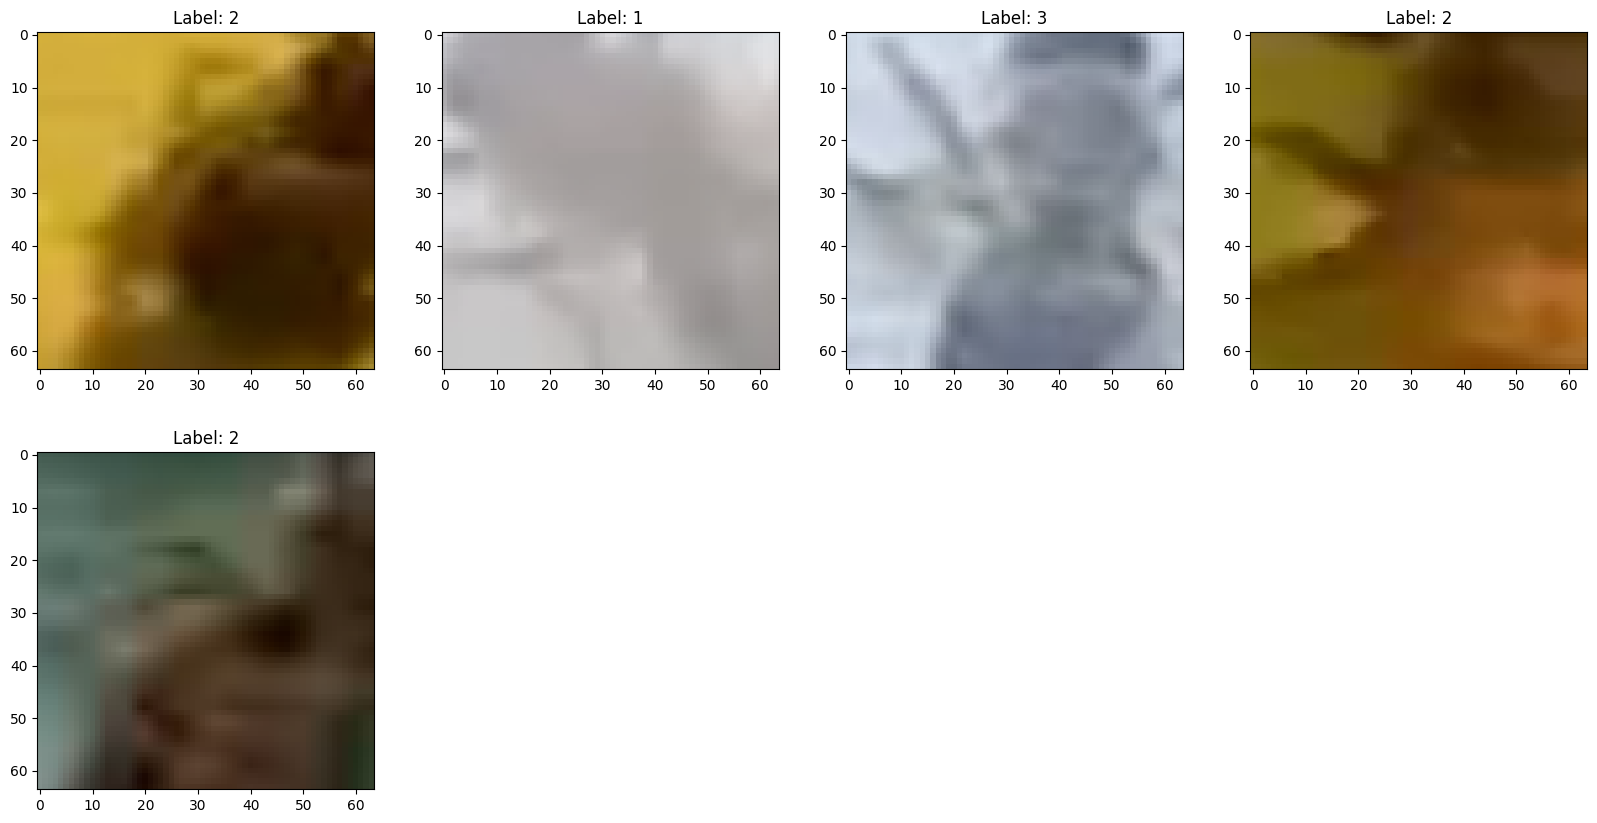

In [42]:
# bee_labels.unique()
# Display images

def display_images(images, labels):
    cols = 4
    rows = math.ceil(len(images) / cols)
    plt.figure(figsize=(20, 10))
    index = 0

    for x in zip(images, labels):
        # image = x[0].cpu()
        # label = x[1].cpu()
        image = x[0]
        label = x[1]
        plt.subplot(rows, cols, index + 1)
        plt.imshow(image, cmap='gray')
        plt.title(f"Label: {label}")
        # plt.axis("off")
        index += 1

# plt.imshow(bee_images[2])

indices = [random.randint(0, X_train.shape[0]) for _ in range(5)]
images = [X_train[index] for index in indices]
labels = [Y_train[index] for index in indices]

display_images(images, labels)


In [43]:
class CustomDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

In [44]:
resized_dims[0] * resized_dims[1] * 64 / 16

np.float64(16384.0)

In [52]:
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()

        # Input image size: 24 * 24 * 3 (3 channels)

        # Layer Set 1: Convolutional Layer -> ReLU Layer -> Pooling Layer
        self.conv_layer_1 = nn.Conv2d(3, 32, kernel_size=5, stride=1, padding=2)
        self.bn_1 = nn.BatchNorm2d(32)
        self.relu_1 = nn.ReLU()

        self.max_pool_1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Layer Set 2: Conv Layer -> ReLU Layer -> Max Pool Layer
        self.conv_layer_2 = nn.Conv2d(32, 64, kernel_size=5, stride=1, padding=2)
        self.bn_2 = nn.BatchNorm2d(64)
        self.relu_2 = nn.ReLU()

        self.max_pool_2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fully Connected layers: Input (509 neurons) -> FC 1 (256 neurons) with ReLU -> FC 2 (128 neurons) with ReLU -> FC 3/Output (6 classes)
        print(resized_dims[0])
        feat_am = 64 * resized_dims[0] * resized_dims[1] // 16
        self.fc_1 = nn.Linear(in_features=feat_am, out_features=256)
        self.fc_1_relu = nn.ReLU()
        self.dropout_1 = nn.Dropout(0.2)

        self.fc_2 = nn.Linear(in_features=256, out_features=128)
        self.fc_2_relu = nn.ReLU()
        self.dropout_2 = nn.Dropout(0.2)

        self.fc_3 = nn.Linear(in_features=128, out_features=6)

    def forward(self, X):
        # Conv Layer 1
        
        # print('0', X.shape)
        out = self.conv_layer_1(X)
        out = self.bn_1(out)
        out = self.relu_1(out)
        # print('1', out.shape)

        out = self.max_pool_1(out)
        # print('1.5', out.shape)

        # Conv Layer 2
        out = self.conv_layer_2(out)
        out = self.bn_2(out)
        out = self.relu_2(out)
        # print('2', out.shape)

        out = self.max_pool_2(out)
        # print('3', out.shape)

        # Flatten
        out = out.reshape(out.size(0), -1)
        # print('4', out.shape)

        # FC Layers
        out = self.fc_1(out)
        out = self.fc_1_relu(out)
        out = self.dropout_1(out)
        # print('5', out.shape)

        out = self.fc_2(out)
        out = self.fc_2_relu(out)
        out = self.dropout_2(out)
        # print('6', out.shape)

        out = self.fc_3(out)
        # print('7', out.shape)

        return out

In [53]:
batch_size = 32
total_epochs = 100
learning_rate = .00005
cnn_model = CNNModel().to(device)

64


In [54]:
error = nn.CrossEntropyLoss()

# SGD Optimizer
optimizer = torch.optim.SGD(cnn_model.parameters(), lr=learning_rate)

In [55]:
# data = Dataset()
# for idx, (data, image) in enumerate(train_dataset):
#     print(idx)
type(X_train)
type(Y_train)

torch.Tensor

In [56]:
train_dataset = CustomDataset(X_train, Y_train)
# rain_dataset = CustomDataset(bee_images,bee_labels)
train_data = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# cnn_model


In [57]:
test = ([X_train],[Y_train])
for (image,label) in enumerate(test):
    print(image,len(label))

0 1
1 1


In [58]:
num_of_iterations = X_train.shape[0] // batch_size
count = 0
loss_list = []
iteration_list = []

training_start_time = time.time()

for epoch in range(total_epochs):
    for i, (images, labels) in enumerate(train_data):
        images = images.float()
        images = images.permute(0, 3, 1, 2)

        # Clear gradients
        optimizer.zero_grad()

        # Forward pass
        output = cnn_model.forward(images)

        # Calculate loss
        loss = error(output, labels)

        # Backpropagation and calculate gradients
        loss.backward()

        # Update parameters
        optimizer.step()

        count += 1
        loss_list.append(loss)
        iteration_list.append(count)

        if i % 4 == 0:
            print(f"Epoch: [{epoch + 1}/{total_epochs}], step: [{i + 1}/{num_of_iterations}], loss: {loss.data:.4f}")
        

training_end_time = time.time()

print(f"\nTotal training time: {training_end_time - training_start_time} seconds")

Epoch: [1/100], step: [1/118], loss: 1.7082
Epoch: [1/100], step: [5/118], loss: 1.7172
Epoch: [1/100], step: [9/118], loss: 1.7126
Epoch: [1/100], step: [13/118], loss: 1.7001
Epoch: [1/100], step: [17/118], loss: 1.6990
Epoch: [1/100], step: [21/118], loss: 1.6989
Epoch: [1/100], step: [25/118], loss: 1.6733
Epoch: [1/100], step: [29/118], loss: 1.6698
Epoch: [1/100], step: [33/118], loss: 1.6707
Epoch: [1/100], step: [37/118], loss: 1.6753
Epoch: [1/100], step: [41/118], loss: 1.6654
Epoch: [1/100], step: [45/118], loss: 1.6359
Epoch: [1/100], step: [49/118], loss: 1.6178
Epoch: [1/100], step: [53/118], loss: 1.6546
Epoch: [1/100], step: [57/118], loss: 1.6335
Epoch: [1/100], step: [61/118], loss: 1.6117
Epoch: [1/100], step: [65/118], loss: 1.5887
Epoch: [1/100], step: [69/118], loss: 1.5829
Epoch: [1/100], step: [73/118], loss: 1.6009
Epoch: [1/100], step: [77/118], loss: 1.6145
Epoch: [1/100], step: [81/118], loss: 1.6295
Epoch: [1/100], step: [85/118], loss: 1.5906
Epoch: [1/100

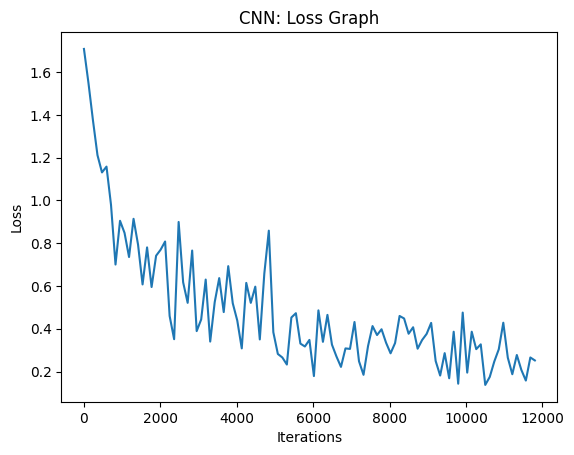

In [59]:
# Loss Graph

loss_list_numpy = np.array([loss.detach().cpu().numpy() for loss in loss_list])[::num_of_iterations]
# iteration_list_stride = i

plt.plot(iteration_list[::num_of_iterations], loss_list_numpy)

plt.xlabel("Iterations")
plt.ylabel("Loss")

plt.title("CNN: Loss Graph")

plt.show()

In [60]:
test_dataset = CustomDataset(X_test, Y_test)

test_data = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [61]:
Y_test.shape


torch.Size([948])

In [62]:
with torch.no_grad():
    total_test = 0
    total_correct = 0

    for i, (images, labels) in enumerate(test_data):
        images = images.float()
        images = images.permute(0, 3, 1, 2)

        output = cnn_model.forward(images)

        _, predictions = torch.max(output, 1)
        # print(predictions.shape, labels.shape)
        # print(predictions, labels)

        total_correct += (predictions == labels).sum().item()
        total_test += labels.shape[0]
        # break

print(f"Total correct predictions: {total_correct}")
print(f"Total samples: {total_test}")
print(f"Accuracy: {total_correct / total_test * 100:.3f}%")

Total correct predictions: 428
Total samples: 948
Accuracy: 45.148%
